In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Student Social Media And Mental Health Impact.csv")

In [3]:
df.shape

(5000, 13)

In [4]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [5]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [6]:
df.duplicated().sum()

np.int64(2)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

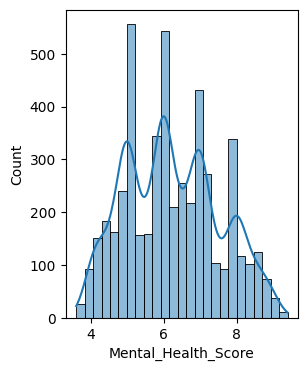

In [8]:
figsize=(3,4)
plt.figure(figsize=figsize)
sns.histplot(df['Mental_Health_Score'],kde='True')

<Axes: >

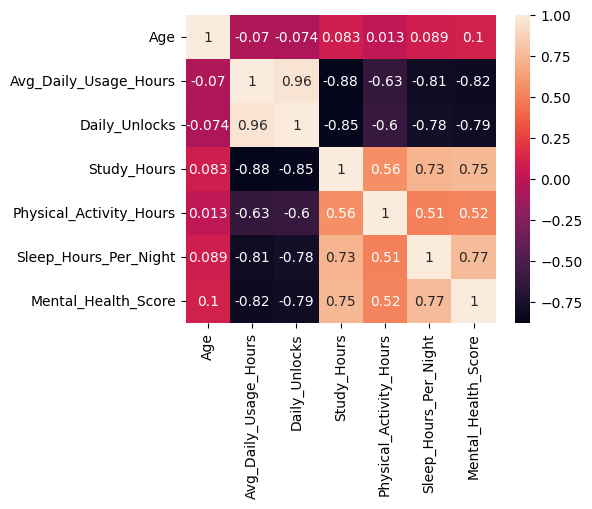

In [9]:
figsize=(5,4)
plt.figure(figsize=figsize)
sns.heatmap(df.corr(numeric_only='True'),annot=True)

In [10]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

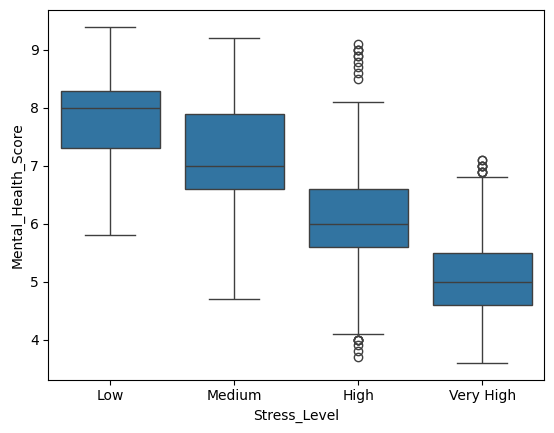

In [11]:
order=['Low','Medium','High','Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score', data=df,order=order )

In [12]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

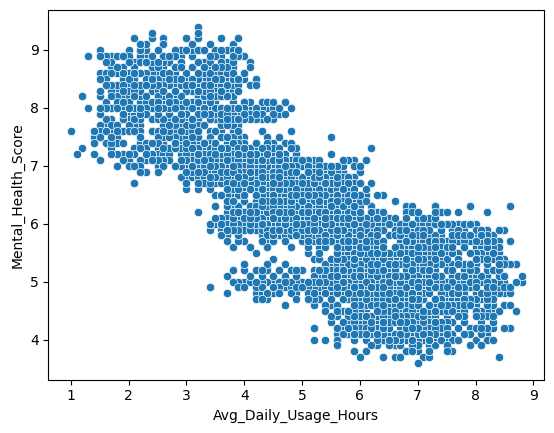

In [13]:
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score',data=df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

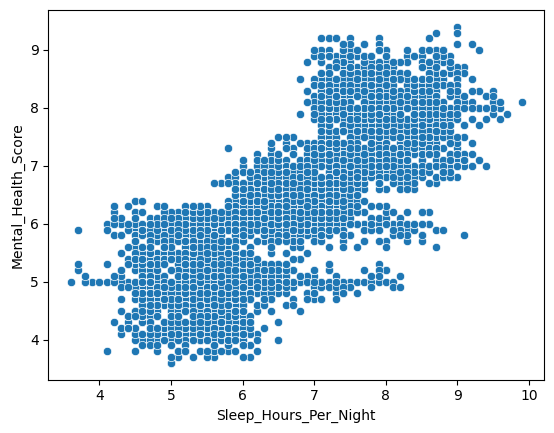

In [14]:
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Mental_Health_Score',data=df)

In [15]:
df['Most_Used_Platform'].value_counts()

,count
Most_Used_Platform,
Instagram,1130
TikTok,918
Facebook,719
LinkedIn,523
YouTube,491
Twitter,462
Snapchat,420
WhatsApp,175
LINE,50


<Axes: xlabel='Most_Used_Platform', ylabel='count'>

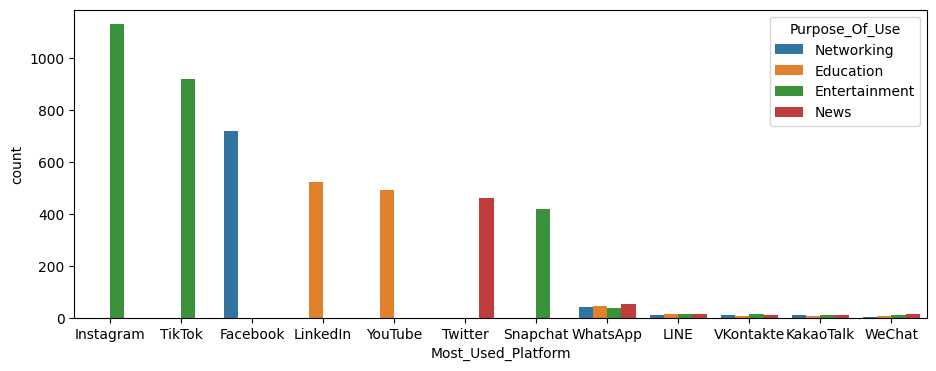

In [16]:
figsize=(11,4)
plt.figure(figsize=figsize)
sns.countplot(x='Most_Used_Platform',data=df,order=df['Most_Used_Platform'].value_counts().index, hue='Purpose_Of_Use')

<Axes: xlabel='Purpose_Of_Use', ylabel='count'>

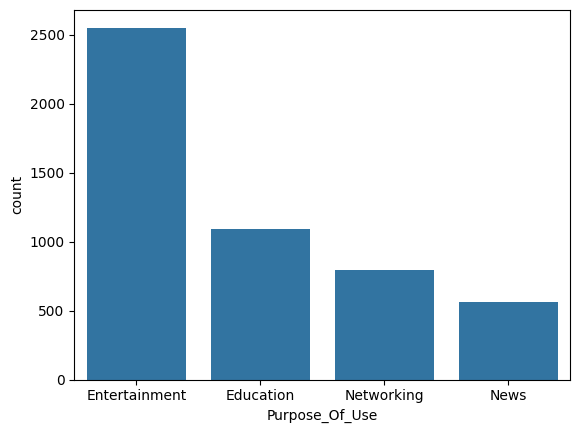

In [17]:

sns.countplot(x='Purpose_Of_Use',data=df,order=df['Purpose_Of_Use'].value_counts().index)


In [18]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [19]:
num_features=df.select_dtypes(include='number')
Q1=num_features.quantile(0.25)
Q3=num_features.quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

In [20]:
outliers=(num_features<lower_bound)|(num_features>upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [21]:
df=df.drop_duplicates()

In [22]:
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

In [23]:
num_features.skew()

,0
Age,0.155325
Avg_Daily_Usage_Hours,0.005606
Daily_Unlocks,0.002351
Study_Hours,0.435819
Physical_Activity_Hours,0.039971
Sleep_Hours_Per_Night,0.124050
Mental_Health_Score,0.206567


In [25]:
top_countries= df['Country'].value_counts().index[:10].tolist()

In [26]:
def grouped_countries(Country):
  if Country in top_countries:
    return Country
  else:
    return 'Other'


df['Grouped_Country']=df['Country'].apply(grouped_countries)

In [27]:
df['Grouped_Country'].value_counts()

,count
Grouped_Country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


In [28]:
df.shape

(4998, 14)

In [29]:
df['Country']

,Country
0,Other
1,Other
2,Canada
3,Other
4,Other
...,...
4995,Other
4996,Other
4997,India
4998,Other


In [34]:
from sklearn.model_selection import train_test_split

skewed_cols=['Study_Hours']
other_num_cols=["Age",	"Avg_Daily_Usage_Hours",	"Daily_Unlocks",		"Physical_Activity_Hours",	"Sleep_Hours_Per_Night"]
ordinal_cols=['Stress_Level']
normal_cols=['Gender','Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use','Grouped_Country']

feature_cols=skewed_cols+other_num_cols+ordinal_cols+normal_cols
X=df[feature_cols]
y=df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
#1. Skewed features
skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())

])

#2. Numeric Features
plain_numeric_pipeline = Pipeline(steps=[
    ('scale',StandardScaler())
])

#3. Ordinal
ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

#4. Nominal Features
nominal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown="ignore"))
])


    # (konsi_pipeline, konsa_feature)
preprocessor = ColumnTransformer(transformers=[
    ("Skewed_Pipeline", skew_pipeline, skewed_cols),
    ("Plain_Numeric",plain_numeric_pipeline, other_num_cols ),
    ('Ordinal', ordinal_pipeline, ordinal_cols),
    ('Normal', nominal_pipeline, normal_cols)
])



In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
lr_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])
lr_pipeline.fit(X_train,y_train)
lr_preds=lr_pipeline.predict(X_test)
lr_preds_training =lr_pipeline.predict(X_train)

lr_r2_testing=r2_score(y_test,lr_preds)
lr_r2_training=r2_score(y_train,lr_preds_training)
lr_mean_ae=mean_absolute_error(y_test,lr_preds)


print(f"Testing R2 Score: {lr_r2_testing}")
print(f"Training R2 Score: {lr_r2_training}")
print(f"Mean Squared Error: {lr_mean_ae}")
#

Testing R2 Score: 0.7397944617433021
Training R2 Score: 0.7236771199387538
Mean Squared Error: 0.5361775634720181


In [50]:
from sklearn.ensemble import RandomForestRegressor
rf_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',RandomForestRegressor(random_state=42))
])
rf_pipeline.fit(X_train,y_train)

rf_preds=rf_pipeline.predict(X_test)
rf_preds_training=rf_pipeline.predict(X_train)

rf_r2_testing=r2_score(y_test,rf_preds)
rf_r2_training=r2_score(y_train,rf_preds_training)
rf_mean_ae=mean_absolute_error(y_test,rf_preds)

print(f"Testing R2 Score: {rf_r2_testing}")
print(f"Training R2 Score: {rf_r2_training}")
print(f"Mean Squared Error: {rf_mean_ae}")
#


Testing R2 Score: 0.8775888638668996
Training R2 Score: 0.9808287942404612
Mean Squared Error: 0.34722113333333343


In [55]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'model__n_estimators'       : [100,200,300],
    'model__max_depth'         : [5,10,15],
    'model__min_samples_split' : [2,5,10],
    'model__min_samples_leaf'  : [1,2,4]
}
randomSearch=RandomizedSearchCV(
     estimator=rf_pipeline,
     param_distributions=param_grid,
     n_iter=5,
     cv=5,
      scoring='r2',
     verbose=2,
     random_state=42,
     n_jobs=-1
 )


In [56]:
randomSearch.fit(X_train,y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Skewed_Pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('Plain_Numeric',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlocks',
                                                                                'Ph...
                                                                               ['Gender',
                                                                                'Academic_Level',
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'Grouped_Country'])])),
                                             ('model',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'model__max_depth': [5, 10, 15],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='r2', verbose=2)

In [57]:
randomSearch.best_params_

{'model__n_estimators': 200,
 'model__min_samples_split': 5,
 'model__min_samples_leaf': 1,
 'model__max_depth': 10}

In [61]:
rf_bestpipeline=randomSearch.best_estimator_
rf_best_preds=rf_bestpipeline.predict(X_test)

In [64]:
print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test, rf_best_preds)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(y_test, rf_best_preds)}")

R2 Score for random forest after hyperparameter tuning 0.8401039307672222
MAE Score for random forest after hyperparameter tuning 0.40886067191259584


In [65]:
import joblib
joblib.dump(rf_pipeline,"Mental_Health_model.pkl")

['Mental_Health_model.pkl']